In [1]:
import sys
import os

# !pip install pandas
# !pip install seaborn
# !pip install qiskit-aer
import pandas as pd
import numpy as np

import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skewnorm, t, chi2, gamma
from scipy.stats import kstest
import json
import math

from qiskit.synthesis import LieTrotter
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit
from qiskit.quantum_info import SparsePauliOp

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'utils'))
if src_path not in sys.path:
    sys.path.append(src_path)

from qiskit_addon_obp.classical_shadows import run_shadow, calculate_shadow_sample_complexity
from qiskit_addon_obp.run import run_many, obp_protocol
from qiskit_addon_obp.obp import run_backpropagation

In [2]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
import rustworkx as rx
from qiskit.compiler import transpile

In [32]:
def create_n_regular_graph(n, k):
    graph = rx.PyGraph()
    graph.add_nodes_from(range(n))
    edge_list = []
    for i in range(n):
        for j in range(1, k // 2 + 1):
            edge_list.append((i, (i + j) % n, 1.0))

    if k % 2 == 1:
        for i in range(n):
            edge_list.append((i, (i + n // 2) % n, 1.0))
    graph.add_edges_from(edge_list)
    return graph

graph = create_n_regular_graph(5, 3)
print(graph)

In [70]:
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.
 
    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list
 
 
max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, 5)
print("Cost Function Hamiltonian:", str(cost_hamiltonian.paulis))

Cost Function Hamiltonian: ['IIIZZ', 'IIZZI', 'IZZII', 'ZZIII', 'ZIIIZ', 'IIZIZ', 'IZIZI', 'ZIZII',
 'IZIIZ', 'ZIIZI']


In [77]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit = transpile(circuit, basis_gates=['cx', 'rz', 'rx', 'h'])

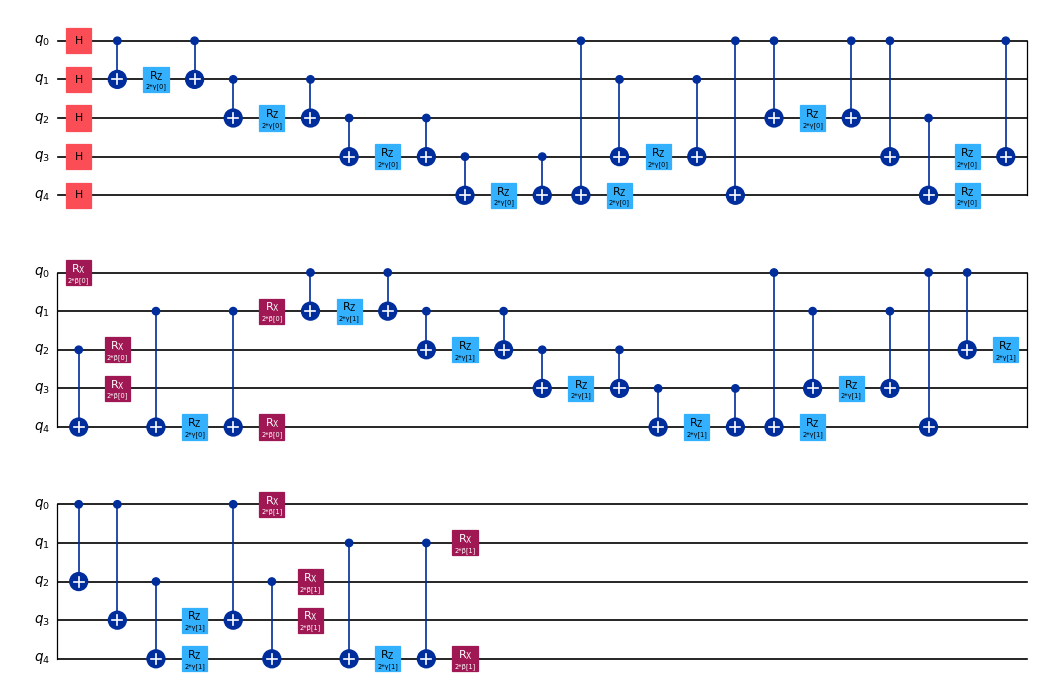

In [78]:
circuit.draw("mpl", style="iqp", scale=0.6)
# print(circuit.depth())

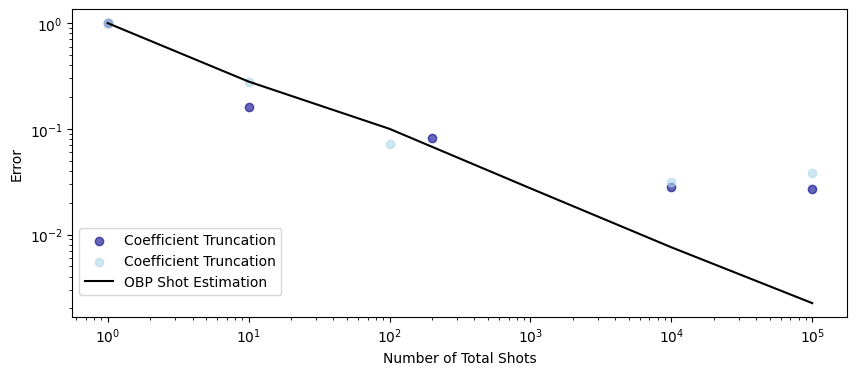

In [56]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'QAOA_data'))
# noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

bp_depth_100 = pd.read_pickle(f'{data_path}/bp_depth_100.pkl')
bp_depth_80 = pd.read_pickle(f'{data_path}/bp_depth_80.pkl')

obp_df = pd.read_pickle(f'{data_path}/obp_bp80.pkl')

# noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
# obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
# shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 10
bp_depth_100['obs_group'] = bp_depth_100.index // obs_num
bp_depth_80['obs_group'] = bp_depth_80.index // obs_num
# noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
# shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb100 = bp_depth_100.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb80 = bp_depth_80.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
# gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

# gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb100['num_meas'], y=gb100['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb80['num_meas'], y=gb80['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
# sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
# plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

# print(obp_df['num_qwc_bp_obs'].mean())

# y_hline = gb1['abs_total_error'].min()
# y_hline = sorted(gb_noisy['abs_total_error'])[1]
# print(gb1[gb1['abs_total_error'] == y_hline])
# y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
# diff = gb_obp['abs_bp_error_shots'] - y_hline
# crossings = diff.shift(-1) * diff < 0
# for idx in gb_obp.index[crossings]:
#     x0 = gb_obp.loc[idx, 'num_total_shots']
#     y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
#     x1 = gb_obp.loc[idx + 1, 'num_total_shots']
#     y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
#     # Linear interpolation
#     if y1 != y0:
#         x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
#         print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
#         print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

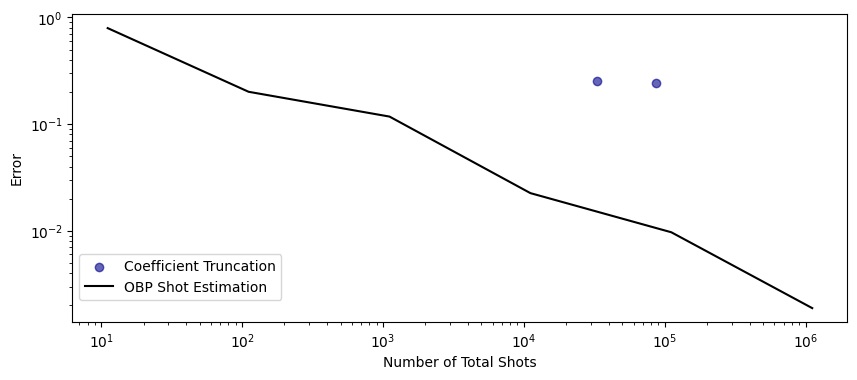

In [88]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'QAOA_data'))
# noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

test = pd.read_pickle(f'{data_path}/bp-shad_reps5_n4_k3_g073_b042_depth70.pkl')

obp_df = pd.read_pickle(f'{data_path}/obp_reps5_n4_k3_g073_b042_depth70.pkl')

# noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
# obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
# shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 8
test['obs_group'] = test.index // obs_num
# noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
# shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb100 = test.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
# gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

# gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb100['num_meas'], y=gb100['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')

# plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
# plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
# sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
# plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

In [87]:
test

,backpropagated slices,number of terms,number of groups,max error,error is bounded by,bp_obs,bp_circuit,obs,circuit,bp_circuit_depth,...,obs_shad_dict,num_meas,circuit_depth,abs_bp_error_shots,bp_error_shots,abs_bp_error_state,bp_error_state,abs_total_error,total_error,obs_group
0,16,25,8,0.0001,0.000000,"[[[SparsePauliOp(['IIZI'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",IIZZ,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.010262,-0.010262,9.020562e-17,9.020562e-17,0.123756,-0.123756,0
1,16,24,9,0.0001,0.001335,"[[[SparsePauliOp(['IZZZ'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",IZZI,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.008599,-0.008599,1.572046e-05,-1.572046e-05,0.562533,-0.562533,0
2,16,25,9,0.0001,0.000000,"[[[SparsePauliOp(['ZZII'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",ZZII,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.004151,-0.004151,4.163336e-16,4.163336e-16,0.102623,-0.102623,0
3,16,24,15,0.0001,0.001335,"[[[SparsePauliOp(['ZIIZ'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",ZIIZ,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.021160,0.021160,1.572046e-05,-1.572046e-05,0.563137,-0.563137,0
4,16,25,15,0.0001,0.000750,"[[[SparsePauliOp(['IZIZ'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",IZIZ,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.001593,-0.001593,1.343796e-04,1.343796e-04,0.121743,0.121743,0
5,16,25,9,0.0001,0.000750,"[[[SparsePauliOp(['ZIZZ'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",ZIZI,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.011572,0.011572,1.343796e-04,1.343796e-04,0.174883,0.174883,0
6,16,25,15,0.0001,0.000750,"[[[SparsePauliOp(['IZIZ'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",IZIZ,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.000916,-0.000916,1.343796e-04,1.343796e-04,0.121743,0.121743,0
7,16,25,9,0.0001,0.000750,"[[[SparsePauliOp(['ZIZZ'],\n coef...","((Instruction(name='h', num_qubits=1, num_clbi...",ZIZI,"((Instruction(name='h', num_qubits=1, num_clbi...",70,...,"[{'obs': 'IIZI', 'estimate': -0.01024534915071...",86000,86,0.010048,-0.010048,1.343796e-04,1.343796e-04,0.174883,0.174883,0
